In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/bike_data_clean.csv', parse_dates=['date'])
df.head()

,date,rented_bike_count,temperature,humidity,wind_speed,visibility,solar_radiation,rainfall,snowfall,is_weekend,hour_sin,hour_cos,seasons_Spring,seasons_Summer,seasons_Winter,holiday_No Holiday
0,2017-12-01,254,-5.2,37,2.2,2000,0.0,0.0,0.0,0,0.000000,1.000000,False,False,True,True
1,2017-12-01,204,-5.5,38,0.8,2000,0.0,0.0,0.0,0,0.258819,0.965926,False,False,True,True
2,2017-12-01,173,-6.0,39,1.0,2000,0.0,0.0,0.0,0,0.500000,0.866025,False,False,True,True
3,2017-12-01,107,-6.2,40,0.9,2000,0.0,0.0,0.0,0,0.707107,0.707107,False,False,True,True
4,2017-12-01,78,-6.0,36,2.3,2000,0.0,0.0,0.0,0,0.866025,0.500000,False,False,True,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                8465 non-null   datetime64[ns]
 1   rented_bike_count   8465 non-null   int64         
 2   temperature         8465 non-null   float64       
 3   humidity            8465 non-null   int64         
 4   wind_speed          8465 non-null   float64       
 5   visibility          8465 non-null   int64         
 6   solar_radiation     8465 non-null   float64       
 7   rainfall            8465 non-null   float64       
 8   snowfall            8465 non-null   float64       
 9   is_weekend          8465 non-null   int64         
 10  hour_sin            8465 non-null   float64       
 11  hour_cos            8465 non-null   float64       
 12  seasons_Spring      8465 non-null   bool          
 13  seasons_Summer      8465 non-null   bool        

In [4]:
df = df.sort_values('date').reset_index(drop=True)
split_idx = int(len(df) * 0.85)

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

print(train['date'].min(), '-', train['date'].max())
print(test['date'].min(), '-', test['date'].max())

2017-12-01 00:00:00 - 2018-10-03 00:00:00
2018-10-03 00:00:00 - 2018-11-30 00:00:00


In [5]:
train[['seasons_Spring', 'seasons_Summer', 'seasons_Winter']].sum()


seasons_Spring    2160
seasons_Summer    2208
seasons_Winter    2160
dtype: int64

In [6]:
test[['seasons_Spring', 'seasons_Summer', 'seasons_Winter']].sum()

seasons_Spring    0
seasons_Summer    0
seasons_Winter    0
dtype: int64

In [7]:
feature_cols = [col for col in df.columns if col not in ['date', 'rented_bike_count']]

X_train = train[feature_cols]
y_train = train['rented_bike_count']
X_test = test[feature_cols]
y_test = test['rented_bike_count']

X_train.shape, X_test.shape

((7195, 14), (1270, 14))

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# MAE: average prediction error, in actual bike count units
mae = mean_absolute_error(y_test, y_pred_lr)

# RMSE: similar to MAE, but penalizes large errors more heavily
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# R²: proportion of variance in demand explained by the model (0-1, higher is better)
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE: {mae:.1f}")
print(f"RMSE: {rmse:.1f}")
print(f"R²: {r2:.3f}")

MAE: 315.3
RMSE: 412.9
R²: 0.439


In [9]:
naive_pred = np.full_like(y_test, y_train.mean(), dtype=float)

naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))

print(f"Naive MAE: {naive_mae:.1f}")
print(f"Naive RMSE: {naive_rmse:.1f}")

Naive MAE: 442.2
Naive RMSE: 565.3


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE: {mae_rf:.1f}")
print(f"RMSE: {rmse_rf:.1f}")
print(f"R²: {r2_rf:.3f}")

MAE: 258.1
RMSE: 353.3
R²: 0.589


In [11]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print(f"MAE: {mae_gb:.1f}")
print(f"RMSE: {rmse_gb:.1f}")
print(f"R²: {r2_gb:.3f}")

MAE: 268.9
RMSE: 370.5
R²: 0.548


In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'subsample': [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42
)

gb_search.fit(X_train, y_train)
gb_search.best_params_

{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05}

In [12]:
best_gb = gb_search.best_estimator_
y_pred_gb_tuned = best_gb.predict(X_test)

mae_gb_tuned = mean_absolute_error(y_test, y_pred_gb_tuned)
rmse_gb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned))
r2_gb_tuned = r2_score(y_test, y_pred_gb_tuned)

print(f"MAE: {mae_gb_tuned:.1f}")
print(f"RMSE: {rmse_gb_tuned:.1f}")
print(f"R²: {r2_gb_tuned:.3f}")

NameError: name 'gb_search' is not defined

In [13]:
# ## Modeling

# Split data by date (85/15), not randomly - train is Dec 2017-Oct 2018 (all seasons),
# test is Oct-Nov 2018 (Autumn only).

# Results (MAE / RMSE / R²):
# - Naive baseline (always predict mean):  442.2 / 565.3 / 0.000
# - Linear Regression:                      315.3 / 412.9 / 0.439
# - Random Forest:                          258.1 / 353.3 / 0.589  <- best
# - Gradient Boosting (default settings):   268.9 / 370.5 / 0.548
# - Gradient Boosting (tuned):               272.7 / 374.3 / 0.539

# Random Forest performed best and is used as the final model.
# Tuning Gradient Boosting did not help - it stayed worse than Random Forest.
# Linear Regression is clearly weaker, matching what we saw in EDA: 
# demand has sharp non-linear patterns (rush hour peaks) that a straight-line 
# model can't capture well.


<Axes: >

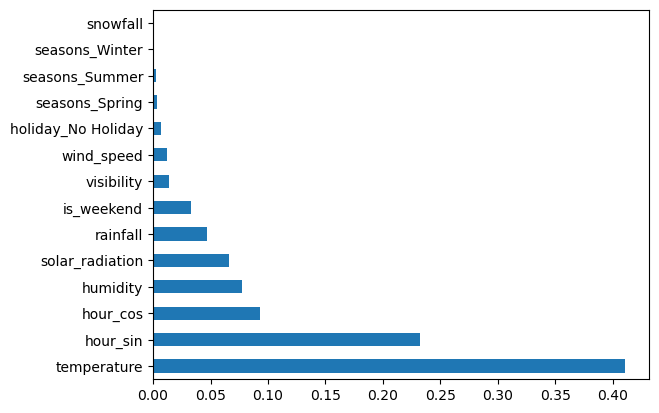

In [14]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.plot(kind='barh')

In [15]:
!pip install shap

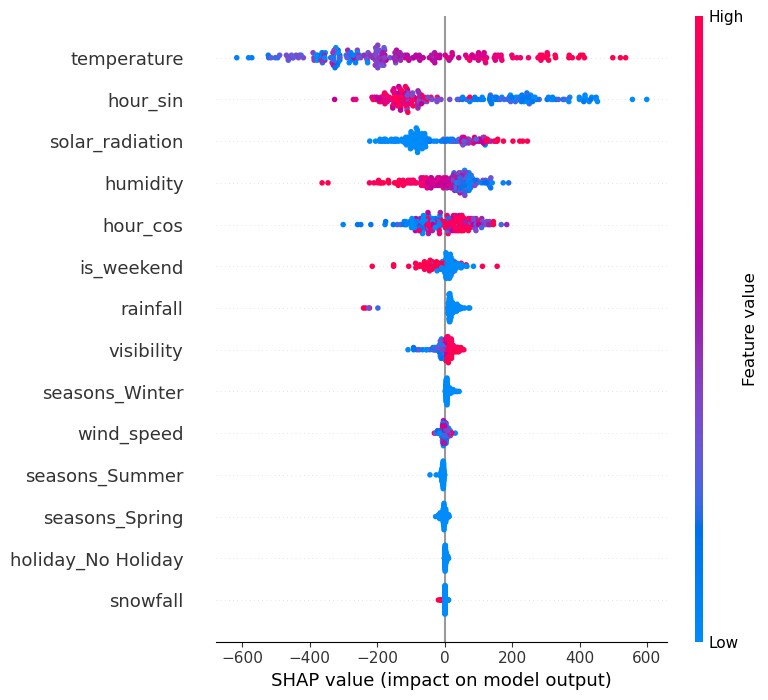

In [16]:
import shap

X_sample = X_test.sample(200, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

shap.summary_plot(shap_values, X_sample)

In [17]:
# ## Interpretation (Feature Importance + SHAP)

# Feature importance (Random Forest):
# - temperature is the single most important feature (0.41)
# - hour (hour_sin + hour_cos combined) is second most important (~0.32)
# - humidity, solar_radiation, rainfall have moderate impact
# - season columns (Winter/Summer/Spring) have almost no importance on their own -
#   likely because temperature already captures most of that information
# - is_weekend has low importance by this measure, but SHAP confirms it still 
#   matters for shaping *when* demand happens, not just how much

# SHAP confirms the direction of each effect:
# - higher temperature -> higher predicted demand
# - higher solar radiation -> higher predicted demand (sunny days beyond just being warm)
# - rainfall -> lower predicted demand, though most hours have no rain at all
# - temperature and hour have the widest impact range, meaning they can push 
#   predictions up or down the most depending on conditions

# Overall: weather (mainly temperature) and time of day are the two main drivers 
# of bike demand in this model, matching what we already saw in EDA.